C:\Users\Zepspel\AppData\Local\Temp\ipykernel_10788\1934729120.py:20: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(CSV_PATH)


Classes: ['control', 'endo', 'exo']
Samples: 61950 | Spectrum points: 1015 | Unique regions: 7
Feature matrix: (61950, 1179)
First columns: ['region', 'Wave_926.8', 'Wave_927.9', 'Wave_929.1', 'Wave_930.3', 'Wave_931.4', 'Wave_932.6', 'Wave_933.8', 'Wave_935.0', 'Wave_936.1']
0:	learn: 0.5961255	test: 0.5897137	best: 0.5897137 (0)	total: 181ms	remaining: 4m 31s
100:	learn: 0.8834622	test: 0.8365453	best: 0.8365453 (100)	total: 17.8s	remaining: 4m 7s
200:	learn: 0.9410872	test: 0.8454570	best: 0.8459679 (193)	total: 37.5s	remaining: 4m 2s
300:	learn: 0.9733330	test: 0.8504295	best: 0.8508237 (295)	total: 59.1s	remaining: 3m 55s
400:	learn: 0.9904453	test: 0.8533266	best: 0.8537847 (359)	total: 1m 17s	remaining: 3m 33s
500:	learn: 0.9974607	test: 0.8551877	best: 0.8557134 (478)	total: 1m 36s	remaining: 3m 11s
600:	learn: 0.9993114	test: 0.8581177	best: 0.8581808 (598)	total: 1m 54s	remaining: 2m 51s
700:	learn: 0.9998493	test: 0.8608192	best: 0.8608220 (695)	total: 2m 13s	remaining: 2m 3

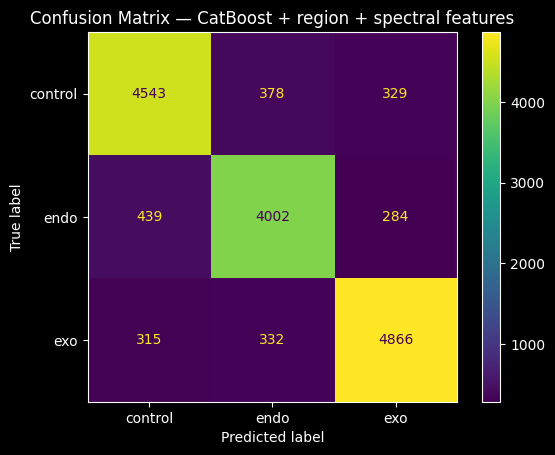


Top-20 features by CatBoost importance:
       feature  importance
        region   16.521914
   Wave_1292.3    2.637260
   Wave_1295.6    2.502879
   Wave_1287.9    2.445961
  D_Global_std    2.233752
   Wave_1293.4    1.541000
Frac_P1_1785.8    1.032155
   Wave_1291.2    0.993700
Frac_P2_1002.5    0.988200
Frac_P8_1131.8    0.904832
   Wave_1059.0    0.891299
   Wave_1441.7    0.879950
   Wave_1296.7    0.876771
   Wave_1440.6    0.866877
Frac_P7_1061.3    0.820114
   Wave_1134.1    0.677065
   Wave_1437.4    0.630454
   Wave_1436.3    0.614038
   Wave_1060.1    0.556054
   Wave_1961.9    0.536817


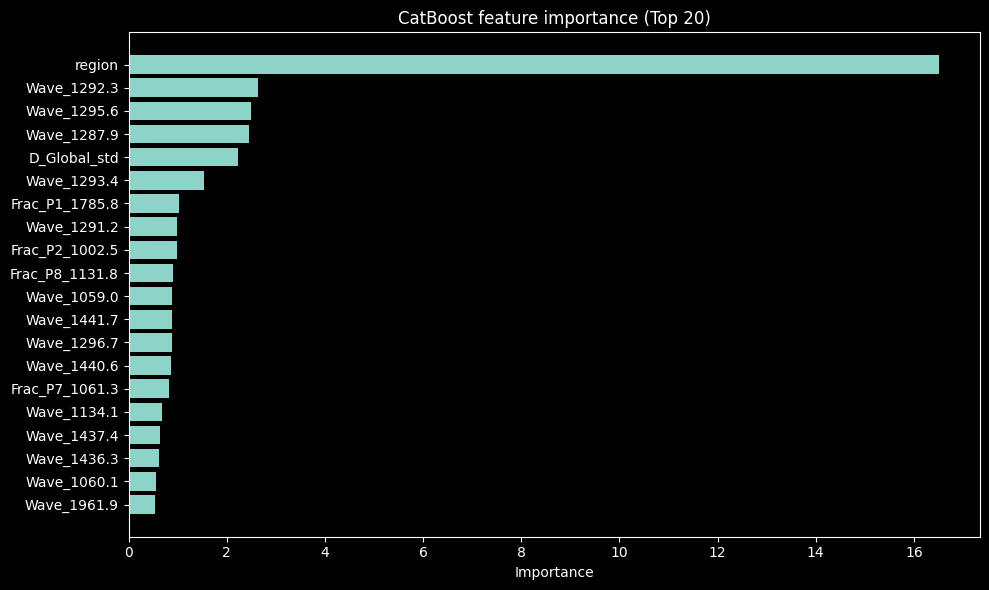

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -------------------- 0) PATH --------------------
CSV_PATH = "mergedData/data_feat_1500_std.csv"

# -------------------- 1) LOAD --------------------
df0 = pd.read_csv(CSV_PATH)

wave_cols = [c for c in df0.columns if str(c).startswith("Wave_")]


def parse_wave(c):
    return float(str(c).split("_", 1)[1])


wave_axis = np.array([parse_wave(c) for c in wave_cols], dtype=float)
order = np.argsort(wave_axis)
wave_axis = wave_axis[order]
wave_cols = [wave_cols[i] for i in order]

df = df0.copy()

for c in wave_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["position", "class"] + wave_cols).reset_index(drop=True)

Xmat = df[wave_cols].to_numpy(dtype=float)
if not np.isfinite(Xmat).all():
    raise ValueError("В интенсивностях есть NaN/inf — сначала почистите данные.")

region = df["position"].astype(str).to_numpy()
y_str = df["class"].astype(str).to_numpy()

le = LabelEncoder()
y = le.fit_transform(y_str)

print("Classes:", list(le.classes_))
print("Samples:", len(df), "| Spectrum points:", Xmat.shape[1], "| Unique regions:", len(np.unique(region)))

# -------------------- 2) FEATURE MATRIX --------------------
F = df.drop(
    ["position", "class", "group", "nm", "center", "obj", "power",
     "during", "acc", "map", "step", "place", "X", "Y"],
    axis=1
)

X_all = pd.concat([pd.DataFrame({"region": region}), F.reset_index(drop=True)], axis=1)

print("Feature matrix:", X_all.shape)
print("First columns:", X_all.columns[:10].tolist())

# -------------------- 3) TRAIN / TEST SPLIT --------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# индекс или имя категориального признака
cat_features = ["region"]

# -------------------- 4) MODEL --------------------
model = CatBoostClassifier(
    iterations=1500,
    depth=10,
    learning_rate=0.1,
    l2_leaf_reg=3,
    border_count=64,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    task_type="GPU",
    devices="0",
    random_seed=42,
    verbose=100
)

# -------------------- 5) TRAIN --------------------
model.fit(
    X_tr,
    y_tr,
    cat_features=cat_features,
    eval_set=(X_te, y_te)
)

# -------------------- 6) PREDICT --------------------
pred = model.predict(X_te).astype(int).flatten()

acc = accuracy_score(y_te, pred)
f1m = f1_score(y_te, pred, average="macro")

print("\nHoldout (stratified) metrics:")
print("Accuracy:", f"{acc:.6f}")
print("F1 macro:", f"{f1m:.6f}")
print(classification_report(y_te, pred, target_names=le.classes_))

# -------------------- 7) CONFUSION MATRIX --------------------
cm = confusion_matrix(y_te, pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()
plt.title("Confusion Matrix — CatBoost + region + spectral features")
plt.show()

# -------------------- 8) FEATURE IMPORTANCE --------------------
importances = model.get_feature_importance(type="FeatureImportance")

imp_df = pd.DataFrame({
    "feature": X_tr.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop-20 features by CatBoost importance:")
print(imp_df.head(20).to_string(index=False))

top = imp_df.head(20).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top["feature"], top["importance"])
plt.title("CatBoost feature importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Holdout (stratified) metrics:
Accuracy: 0.865896
F1 macro: 0.865000
              precision    recall  f1-score   support

     control       0.86      0.87      0.86      5250
        endo       0.85      0.85      0.85      4725
         exo       0.89      0.88      0.89      5513

    accuracy                           0.87     15488
   macro avg       0.87      0.86      0.86     15488
weighted avg       0.87      0.87      0.87     15488



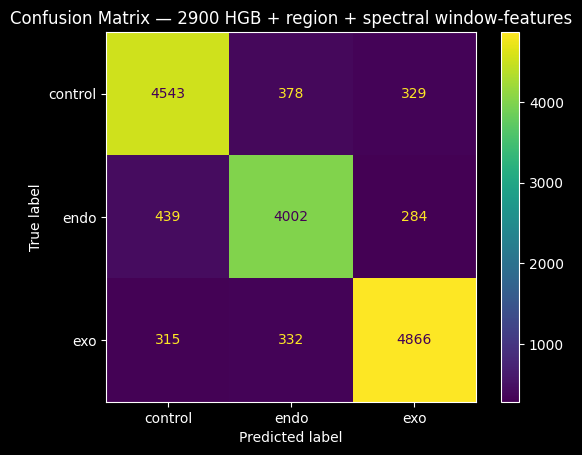

In [2]:
acc = accuracy_score(y_te, pred)
f1m = f1_score(y_te, pred, average="macro")
print("\nHoldout (stratified) metrics:")
print("Accuracy:", f"{acc:.6f}")
print("F1 macro:", f"{f1m:.6f}")
print(classification_report(y_te, pred, target_names=le.classes_))

cm = confusion_matrix(y_te, pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot()
plt.title("Confusion Matrix — 2900 HGB + region + spectral window-features")
plt.show()